# Identifiability: cath lab vs Pas+HR

Compares posterior width per parameter between:
- **A1** (`exp-v1_enc-pashr_maf5_sims`): only Pas waveform + HR — minimal cath input
- **B1** (`exp-v1_enc-cathlab_maf5_sims`): Prv, Pra, Pvp, Pap + 5 scalars — full cath lab

Both flows trained on 1M sims with the same architecture (MAF5, 128-dim encoder).
Evaluated on held-out test sims where true theta is known.

**Key questions:**
1. Which parameters are identifiable from Pas+HR alone?
2. What does adding Prv/Pra/Pvp (right-heart pressures) buy?
3. Is SV from posterior theta (via S1 surrogate) better constrained by cath lab?

In [1]:
import json, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from scipy.stats import pearsonr

try:
    ROOT = Path(globals()['_dh'][0]).parent
    assert (ROOT / 'dataset.py').exists()
except:
    ROOT = Path('/home/sa4604/cv-sbi-sim')
sys.path.insert(0, str(ROOT))

from dataset import (
    load_stats, load_manifest,
    ReducedCVDataset, PasHRDataset,
    PARAM_KEYS, PARAM_KEYS_INFER, WAVE_KEYS_CONT,
    N_PARAMS, N_CONT, T, _HR_IDX,
)
from models import ReducedAutoencoderEncoder, PasHREncoder, SurrogateDecoder

SIM_ROOT   = Path('/media/local/SimData/hdf5/cv8/simset_10M_cv8Eed_20260314')
STATS_PATH = ROOT / 'norm_stats.json'
OUT_A1     = ROOT / 'outputs/exp-v1_enc-pashr_maf5_sims'
OUT_B1     = ROOT / 'outputs/exp-v1_enc-cathlab_maf5_sims'
OUT_S1     = ROOT / 'outputs/exp-v1_mlp-surrogate_sims'
CACHE_DIR  = ROOT / 'outputs/identifiability_cache'
CACHE_DIR.mkdir(exist_ok=True)

N_TEST     = 1000
N_SAMPLES  = 1000
device     = torch.device('cuda:0')

stats    = load_stats(STATS_PATH)
manifest = load_manifest(SIM_ROOT / 'manifest_test.json')

# Prior bounds (uniform) for each inferred parameter
manifest_train = load_manifest(SIM_ROOT / 'manifest_train.json')
prior_lo = np.array([manifest_train['config']['pvar_low'][k]  for k in PARAM_KEYS_INFER])
prior_hi = np.array([manifest_train['config']['pvar_high'][k] for k in PARAM_KEYS_INFER])
prior_std = (prior_hi - prior_lo) / np.sqrt(12)  # uniform dist std

vlv_idx  = WAVE_KEYS_CONT.index('Vlv')
vlv_std  = stats['waves']['Vlv']['std']

print('ROOT:', ROOT)
print('device:', device)
print('prior_std range:', prior_std.min().round(4), '–', prior_std.max().round(4))

ROOT: /home/sa4604/cv-sbi-sim
device: cuda:0
prior_std range: 0.0115 – 779.4229


In [2]:
import time

def run_inference(label, encoder, flow_net, dataset, cache_path):
    """Run flow on N_TEST sims, return theta_true (N, 24) and samples (N, N_SAMPLES, 24)."""
    if cache_path.exists():
        d = np.load(cache_path)
        print(f'[{label}] loaded from cache')
        return d['theta_true'], d['samples']

    print(f'[{label}] running inference on {N_TEST} test sims...')
    theta_list, samples_list = [], []
    t0 = time.time()
    for i in range(N_TEST):
        theta, x = dataset[i]
        with torch.no_grad():
            z = encoder(x.unsqueeze(0).to(device))
            s = flow_net.sample((N_SAMPLES,), condition=z).squeeze(1).cpu()  # (N_SAMPLES, 24)
        theta_list.append(theta.numpy())
        samples_list.append(s.numpy())
        if i % 200 == 0:
            print(f'  {i}/{N_TEST}  ({time.time()-t0:.0f}s)', end='\r', flush=True)

    theta_true = np.stack(theta_list)   # (N_TEST, 24)
    samples    = np.stack(samples_list) # (N_TEST, N_SAMPLES, 24)
    np.savez(cache_path, theta_true=theta_true, samples=samples)
    print(f'[{label}] done  ({time.time()-t0:.0f}s), saved to {cache_path.name}')
    return theta_true, samples


# ── A1: Pas+HR ────────────────────────────────────────────────────────────────
ds_a1 = PasHRDataset(str(SIM_ROOT / 'test'), manifest['index'][:N_TEST], stats)
enc_a1 = PasHREncoder(latent_dim=128).to(device)
enc_a1.load_state_dict(torch.load(OUT_A1 / 'encoder.pt', map_location=device))
enc_a1.eval()
flow_a1 = torch.load(OUT_A1 / 'flow_net.pt', map_location=device, weights_only=False)
flow_a1.eval()

theta_true_a1, samples_a1 = run_inference(
    'A1 (Pas+HR)', enc_a1, flow_a1, ds_a1, CACHE_DIR / 'posterior_a1.npz'
)
del enc_a1, flow_a1; torch.cuda.empty_cache()

# ── B1: cath lab ──────────────────────────────────────────────────────────────
ds_b1 = ReducedCVDataset(str(SIM_ROOT / 'test'), manifest['index'][:N_TEST], stats)
enc_b1 = ReducedAutoencoderEncoder(latent_dim=128).to(device)
enc_b1.load_state_dict(torch.load(OUT_B1 / 'encoder.pt', map_location=device))
enc_b1.eval()
flow_b1 = torch.load(OUT_B1 / 'flow_net.pt', map_location=device, weights_only=False)
flow_b1.eval()

theta_true_b1, samples_b1 = run_inference(
    'B1 (cath lab)', enc_b1, flow_b1, ds_b1, CACHE_DIR / 'posterior_b1.npz'
)
del enc_b1, flow_b1; torch.cuda.empty_cache()

ds_a1.close(); ds_b1.close()
print('Inference complete.')
print(f'theta_true: {theta_true_b1.shape}  samples: {samples_b1.shape}')

/home/sa4604/cv-sbi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[A1 (Pas+HR)] running inference on 1000 test sims...
[A1 (Pas+HR)] done  (54s), saved to posterior_a1.npz
[B1 (cath lab)] running inference on 1000 test sims...
[B1 (cath lab)] done  (51s), saved to posterior_b1.npz
Inference complete.
theta_true: (1000, 24)  samples: (1000, 1000, 24)


## Posterior width per parameter

**Identifiability ratio** = mean posterior std / prior std.  
- 1.0 → observation carries no information (posterior = prior)  
- 0.0 → parameter perfectly constrained by observation

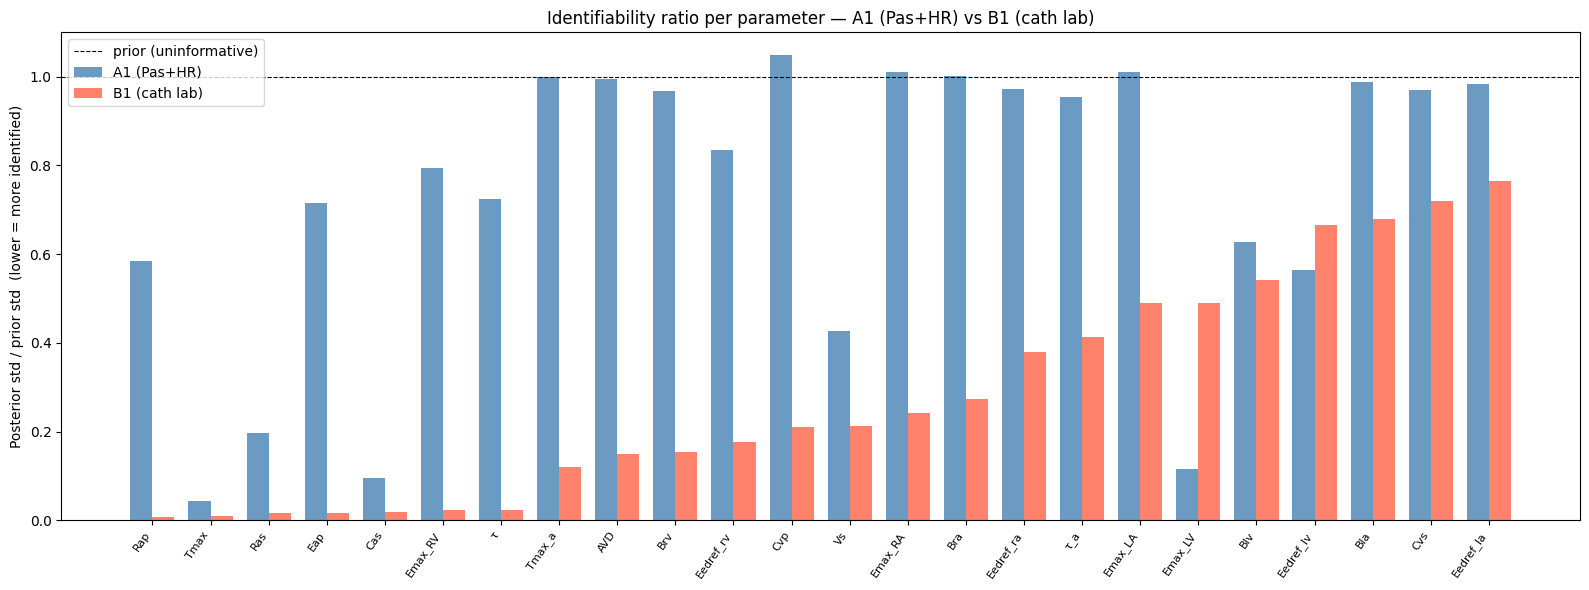


Parameter       Prior std  A1 post std   A1 ratio  B1 post std   B1 ratio
------------------------------------------------------------------------
Rap              343.5234     200.4207      0.583       2.2182      0.006
Tmax              86.6025       3.7663      0.043       0.7444      0.009
Ras              447.4465      87.9304      0.197       7.1457      0.016
Eap                1.4347       1.0249      0.714       0.0244      0.017
Cas                0.7073       0.0679      0.096       0.0139      0.020
Emax_RV            1.0392       0.8248      0.794       0.0239      0.023
τ                 18.7639      13.5968      0.725       0.4449      0.024
Tmax_a            57.7350      57.6524      0.999       6.9906      0.121
AVD               69.2820      68.8577      0.994      10.3874      0.150
Brv                0.0115       0.0112      0.968       0.0018      0.154
Eedref_rv          0.4244       0.3545      0.835       0.0750      0.177
Cvp                2.3094       2.4238

In [3]:
post_std_a1 = samples_a1.std(axis=1).mean(axis=0)  # (24,) mean over test sims
post_std_b1 = samples_b1.std(axis=1).mean(axis=0)

ident_a1 = post_std_a1 / prior_std  # ratio: 1=uninformative, 0=fully identified
ident_b1 = post_std_b1 / prior_std

# Sort by B1 identifiability ratio (most to least identified by cath lab)
order = np.argsort(ident_b1)
params_sorted = [PARAM_KEYS_INFER[i] for i in order]
ia1_s = ident_a1[order]
ib1_s = ident_b1[order]

x = np.arange(len(PARAM_KEYS_INFER))
w = 0.38

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - w/2, ia1_s, w, label='A1 (Pas+HR)',  color='steelblue', alpha=0.8)
ax.bar(x + w/2, ib1_s, w, label='B1 (cath lab)', color='tomato',   alpha=0.8)
ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--', label='prior (uninformative)')
ax.set_xticks(x); ax.set_xticklabels(params_sorted, rotation=55, ha='right', fontsize=8)
ax.set_ylabel('Posterior std / prior std  (lower = more identified)')
ax.set_title('Identifiability ratio per parameter — A1 (Pas+HR) vs B1 (cath lab)', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)
plt.tight_layout(); plt.show()

print(f'\n{"Parameter":<14} {"Prior std":>10} {"A1 post std":>12} {"A1 ratio":>10} {"B1 post std":>12} {"B1 ratio":>10}')
print('-' * 72)
for i in order:
    name = PARAM_KEYS_INFER[i]
    print(f'{name:<14} {prior_std[i]:>10.4f} {post_std_a1[i]:>12.4f} {ident_a1[i]:>10.3f} '
          f'{post_std_b1[i]:>12.4f} {ident_b1[i]:>10.3f}')

## R² and calibration — posterior mean vs true theta

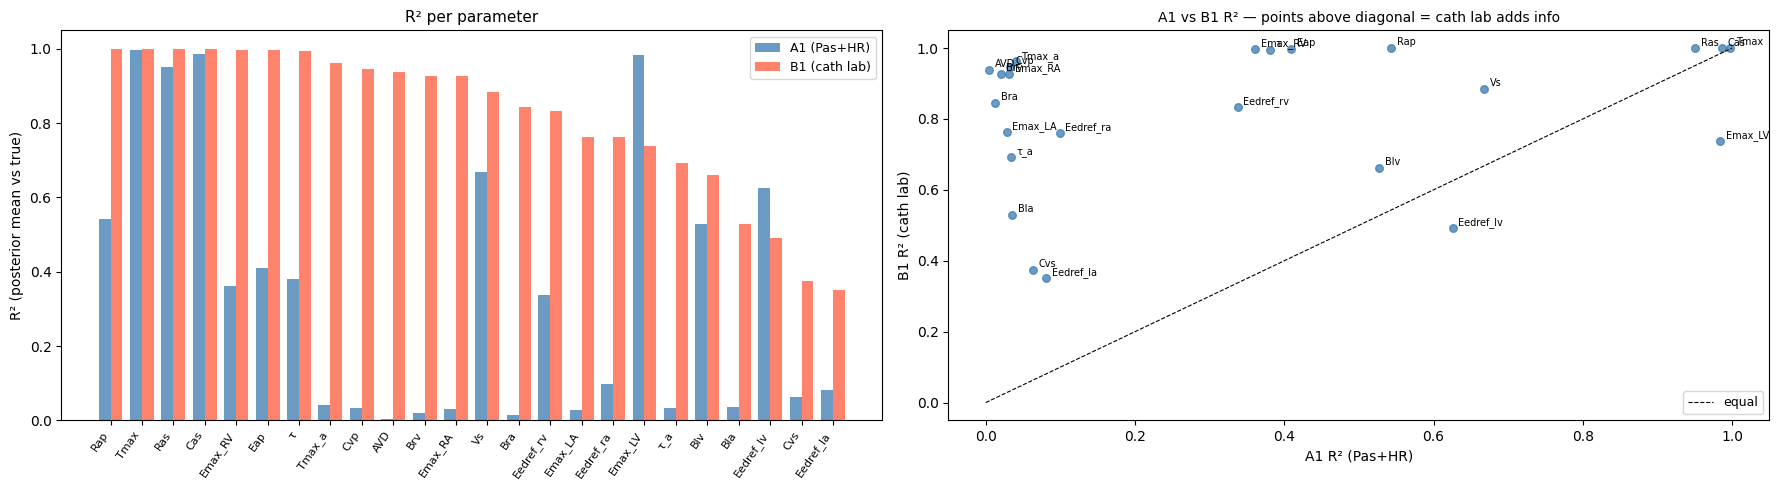


Parameter         A1 R²    B1 R²      ΔR²    A1 MAPE    B1 MAPE
--------------------------------------------------------------
Rap               0.543    1.000   +0.457     202.7%        1.0%
Tmax              0.997    1.000   +0.002       1.2%        0.2%  ← Pas+HR sufficient
Ras               0.951    0.999   +0.048       5.0%        0.4%  ← Pas+HR sufficient
Cas               0.987    0.999   +0.012       4.1%        0.9%  ← Pas+HR sufficient
Emax_RV           0.361    0.998   +0.637      55.7%        1.3%
Eap               0.409    0.998   +0.589     265.1%        1.2%
τ                 0.381    0.995   +0.614      28.3%        0.8%
Tmax_a            0.040    0.962   +0.922      41.4%        3.9%
Cvp               0.032    0.947   +0.915      71.7%        9.6%
AVD               0.004    0.939   +0.935      43.5%        5.7%
Brv               0.020    0.927   +0.907      27.8%        3.8%
Emax_RA           0.032    0.926   +0.895      64.2%       10.9%
Vs                0.668    0.

In [4]:
means_a1 = samples_a1.mean(axis=1)  # (N_TEST, 24)
means_b1 = samples_b1.mean(axis=1)

r2_a1, mape_a1 = np.zeros(24), np.zeros(24)
r2_b1, mape_b1 = np.zeros(24), np.zeros(24)

for i in range(24):
    t, pa, pb = theta_true_b1[:, i], means_a1[:, i], means_b1[:, i]
    r2_a1[i]   = pearsonr(t, pa)[0] ** 2
    r2_b1[i]   = pearsonr(t, pb)[0] ** 2
    mape_a1[i] = np.mean(np.abs(pa - t) / (np.abs(t) + 1e-9)) * 100
    mape_b1[i] = np.mean(np.abs(pb - t) / (np.abs(t) + 1e-9)) * 100

# Sorted by B1 R² descending
order_r2 = np.argsort(-r2_b1)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

ax = axes[0]
x = np.arange(24)
ax.bar(x - w/2, r2_a1[order_r2], w, label='A1 (Pas+HR)',  color='steelblue', alpha=0.8)
ax.bar(x + w/2, r2_b1[order_r2], w, label='B1 (cath lab)', color='tomato',   alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels([PARAM_KEYS_INFER[i] for i in order_r2],
                                      rotation=55, ha='right', fontsize=8)
ax.set_ylabel('R² (posterior mean vs true)'); ax.set_ylim(0, 1.05)
ax.set_title('R² per parameter', fontsize=11); ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(r2_a1, r2_b1, s=30, alpha=0.8, color='steelblue')
for i, name in enumerate(PARAM_KEYS_INFER):
    if abs(r2_b1[i] - r2_a1[i]) > 0.1 or r2_b1[i] > 0.85:
        ax.annotate(name, (r2_a1[i], r2_b1[i]), fontsize=7, xytext=(4, 2),
                    textcoords='offset points')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='equal')
ax.set_xlabel('A1 R² (Pas+HR)'); ax.set_ylabel('B1 R² (cath lab)')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.set_title('A1 vs B1 R² — points above diagonal = cath lab adds info', fontsize=10)
ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

print(f'\n{"Parameter":<14} {"A1 R²":>8} {"B1 R²":>8} {"ΔR²":>8} {"A1 MAPE":>10} {"B1 MAPE":>10}')
print('-' * 62)
for i in order_r2:
    delta = r2_b1[i] - r2_a1[i]
    flag = '  ← Pas+HR sufficient' if abs(delta) < 0.05 and r2_b1[i] > 0.8 else ''
    print(f'{PARAM_KEYS_INFER[i]:<14} {r2_a1[i]:>8.3f} {r2_b1[i]:>8.3f} {delta:>+8.3f} '
          f'{mape_a1[i]:>9.1f}%  {mape_b1[i]:>9.1f}%{flag}')

## Calibration curves — A1 vs B1 on test sims

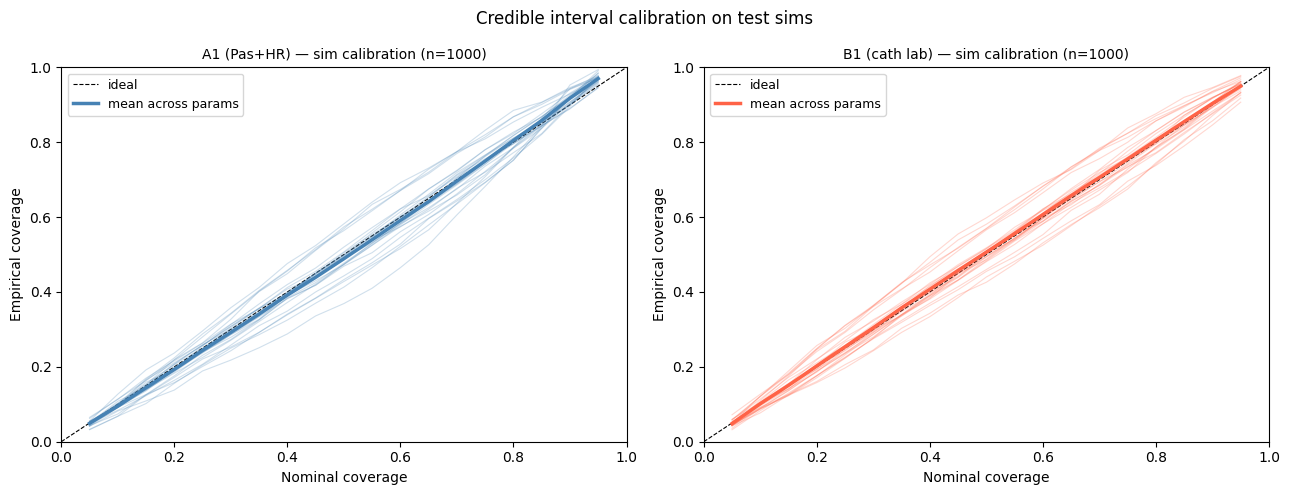

Mean 90% CI coverage:  A1=0.918  B1=0.904  (ideal=0.90)


In [5]:
alphas = np.linspace(0.05, 0.95, 19)
cov_a1 = np.zeros((len(alphas), 24))
cov_b1 = np.zeros((len(alphas), 24))

for ai, alpha in enumerate(alphas):
    lo_q, hi_q = (1 - alpha) / 2 * 100, (100 - (1 - alpha) / 2 * 100)
    lo_a = np.percentile(samples_a1, lo_q, axis=1)  # (N_TEST, 24)
    hi_a = np.percentile(samples_a1, hi_q, axis=1)
    lo_b = np.percentile(samples_b1, lo_q, axis=1)
    hi_b = np.percentile(samples_b1, hi_q, axis=1)
    inside_a = (theta_true_b1 >= lo_a) & (theta_true_b1 <= hi_a)  # (N_TEST, 24)
    inside_b = (theta_true_b1 >= lo_b) & (theta_true_b1 <= hi_b)
    cov_a1[ai] = inside_a.mean(axis=0)
    cov_b1[ai] = inside_b.mean(axis=0)

# Average calibration across all 24 params
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cov, label, color in [
    (axes[0], cov_a1, 'A1 (Pas+HR)',  'steelblue'),
    (axes[1], cov_b1, 'B1 (cath lab)', 'tomato'),
]:
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='ideal')
    for i in range(24):
        ax.plot(alphas, cov[:, i], color=color, alpha=0.25, linewidth=0.8)
    ax.plot(alphas, cov.mean(axis=1), color=color, linewidth=2.5, label='mean across params')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('Nominal coverage'); ax.set_ylabel('Empirical coverage')
    ax.set_title(f'{label} — sim calibration (n={N_TEST})', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Credible interval calibration on test sims', fontsize=12)
plt.tight_layout(); plt.show()

idx_90 = alphas.searchsorted(0.90)
print(f'Mean 90% CI coverage:  A1={cov_a1[idx_90].mean():.3f}  B1={cov_b1[idx_90].mean():.3f}  (ideal=0.90)')

## SV via S1 surrogate

Push posterior theta samples through the surrogate decoder (θ → Vlv waveform), 
then derive SV = (max − min) × vlv_std. Compares how well each observation type 
constrains stroke volume — a clinically important derived quantity.

In [6]:
# Load surrogate and theta normalisation
with open(OUT_S1 / 'theta_norm.json') as f:
    theta_norm = json.load(f)
theta_norm_mean = torch.tensor(theta_norm['mean'], dtype=torch.float32).to(device)  # (25,)
theta_norm_std  = torch.tensor(theta_norm['std'],  dtype=torch.float32).to(device)

surrogate = SurrogateDecoder(hidden=512, n_layers=4).to(device)
surrogate.load_state_dict(torch.load(OUT_S1 / 'decoder.pt', map_location=device))
surrogate.eval()
print('Surrogate loaded:', surrogate.describe())

# Reload true HR from test sims (not inferred — it's part of observation)
# Use the raw dataset (SurrogateDataset returns all 25 params including HR)
from dataset import SurrogateDataset
ds_surr = SurrogateDataset(str(SIM_ROOT / 'test'), manifest['index'][:N_TEST], stats)
hr_true = np.array([ds_surr[i][0][_HR_IDX].item() for i in range(N_TEST)])  # (N_TEST,)
ds_surr.close()

SV_CACHE = CACHE_DIR / 'sv_posteriors.npz'

if SV_CACHE.exists():
    d = np.load(SV_CACHE)
    sv_a1 = d['sv_a1']; sv_b1 = d['sv_b1']; sv_true = d['sv_true']
    print('SV posteriors loaded from cache.')
else:
    def derive_sv(samples_24, hr_true_arr):
        """samples_24: (N_TEST, N_SAMPLES, 24) in raw units; returns sv: (N_TEST, N_SAMPLES) in ml."""
        sv_out = np.zeros((N_TEST, N_SAMPLES))
        for i in range(N_TEST):
            # Reconstruct 25-dim theta by inserting true HR
            s24 = torch.from_numpy(samples_24[i]).float()  # (N_SAMPLES, 24)
            hr_col = torch.full((N_SAMPLES, 1), hr_true_arr[i])
            s25 = torch.cat([s24[:, :_HR_IDX], hr_col, s24[:, _HR_IDX:]], dim=1)  # (N_SAMPLES, 25)
            # Z-score using theta_norm
            s25_z = (s25.to(device) - theta_norm_mean) / theta_norm_std
            with torch.no_grad():
                waves_z = surrogate(s25_z)  # (N_SAMPLES, N_CONT*T)
            waves_z = waves_z.cpu().numpy().reshape(N_SAMPLES, N_CONT, T)
            vlv_z   = waves_z[:, vlv_idx, :]  # (N_SAMPLES, T)
            sv_out[i] = (vlv_z.max(axis=1) - vlv_z.min(axis=1)) * vlv_std
        return sv_out

    print('Deriving SV from A1 posterior...')
    sv_a1 = derive_sv(samples_a1, hr_true)
    print('Deriving SV from B1 posterior...')
    sv_b1 = derive_sv(samples_b1, hr_true)

    # True SV from test sims (using surrogate on true theta for consistency)
    ds_surr2 = SurrogateDataset(str(SIM_ROOT / 'test'), manifest['index'][:N_TEST], stats)
    sv_true_list = []
    for i in range(N_TEST):
        theta_raw, waves_z_true = ds_surr2[i]
        vlv_z_true = waves_z_true.numpy().reshape(N_CONT, T)[vlv_idx]
        sv_true_list.append((vlv_z_true.max() - vlv_z_true.min()) * vlv_std)
    ds_surr2.close()
    sv_true = np.array(sv_true_list)

    np.savez(SV_CACHE, sv_a1=sv_a1, sv_b1=sv_b1, sv_true=sv_true)
    print('SV posteriors computed and cached.')

sv_std_a1 = sv_a1.std(axis=1)  # (N_TEST,) posterior std
sv_std_b1 = sv_b1.std(axis=1)
sv_mean_a1 = sv_a1.mean(axis=1)
sv_mean_b1 = sv_b1.mean(axis=1)

print(f'\nSV posterior std:  A1={sv_std_a1.mean():.2f} ml  B1={sv_std_b1.mean():.2f} ml')
print(f'SV posterior mean vs true:  A1 R²={pearsonr(sv_true, sv_mean_a1)[0]**2:.3f}  '
      f'B1 R²={pearsonr(sv_true, sv_mean_b1)[0]**2:.3f}')

Surrogate loaded: {'type': 'SurrogateDecoder', 'input_dim': 25, 'hidden': 512, 'n_layers': 4, 'output': '(24, 201)', 'n_params': 3013336}
Deriving SV from A1 posterior...
Deriving SV from B1 posterior...
SV posteriors computed and cached.

SV posterior std:  A1=4.59 ml  B1=8.37 ml
SV posterior mean vs true:  A1 R²=0.960  B1 R²=0.913


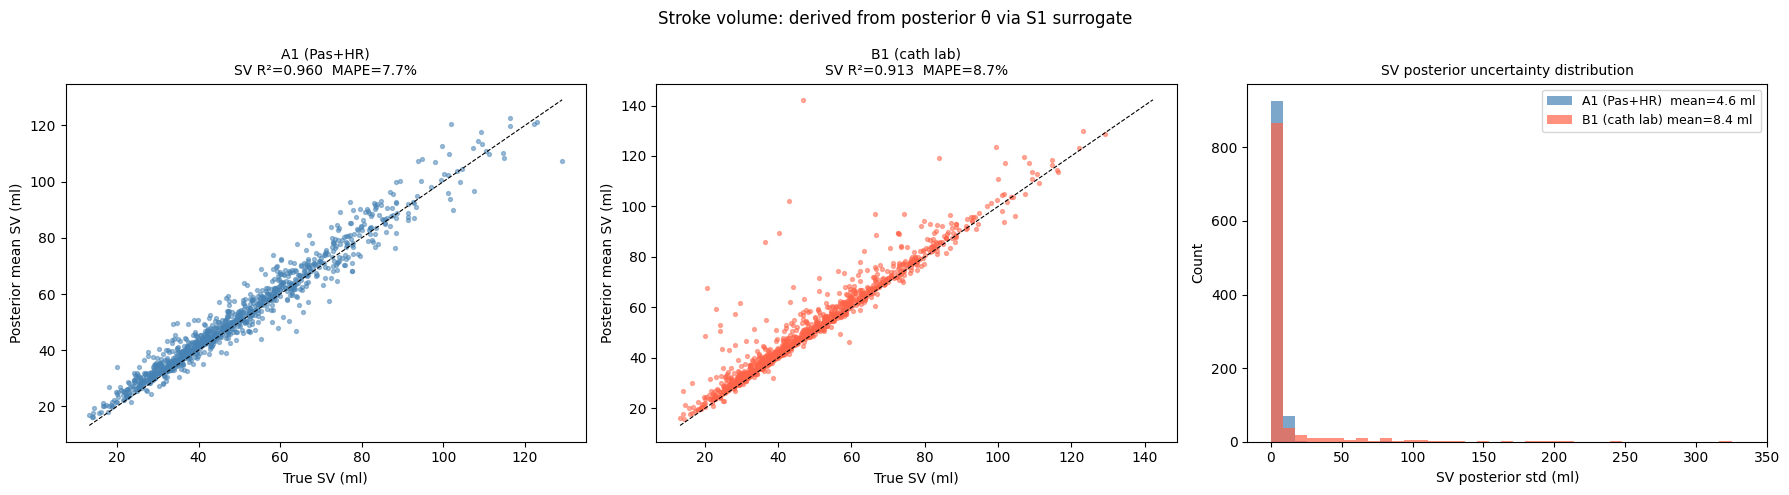

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: posterior mean SV vs true SV
for ax, sv_mean, label, color in [
    (axes[0], sv_mean_a1, 'A1 (Pas+HR)',  'steelblue'),
    (axes[1], sv_mean_b1, 'B1 (cath lab)', 'tomato'),
]:
    lo = min(sv_true.min(), sv_mean.min())
    hi = max(sv_true.max(), sv_mean.max())
    ax.scatter(sv_true, sv_mean, s=8, alpha=0.5, color=color)
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=0.8)
    r2   = pearsonr(sv_true, sv_mean)[0] ** 2
    mape = np.mean(np.abs(sv_mean - sv_true) / (np.abs(sv_true) + 1e-9)) * 100
    ax.set_xlabel('True SV (ml)'); ax.set_ylabel('Posterior mean SV (ml)')
    ax.set_title(f'{label}\nSV R²={r2:.3f}  MAPE={mape:.1f}%', fontsize=10)

# Posterior std comparison
ax = axes[2]
bins = np.linspace(0, max(sv_std_a1.max(), sv_std_b1.max()) * 1.05, 40)
ax.hist(sv_std_a1, bins=bins, color='steelblue', alpha=0.7, label=f'A1 (Pas+HR)  mean={sv_std_a1.mean():.1f} ml')
ax.hist(sv_std_b1, bins=bins, color='tomato',    alpha=0.7, label=f'B1 (cath lab) mean={sv_std_b1.mean():.1f} ml')
ax.set_xlabel('SV posterior std (ml)'); ax.set_ylabel('Count')
ax.set_title('SV posterior uncertainty distribution', fontsize=10)
ax.legend(fontsize=9)

fig.suptitle('Stroke volume: derived from posterior θ via S1 surrogate', fontsize=12)
plt.tight_layout(); plt.show()

## Summary table

In [8]:
print(f'{"Parameter":<14} {"Prior std":>10} {"A1 ratio":>9} {"A1 R²":>8} {"B1 ratio":>9} {"B1 R²":>8}  Info gain')
print('-' * 80)

for i in order:  # sorted by B1 identifiability (most identified first)
    name = PARAM_KEYS_INFER[i]
    a1_r, b1_r = ident_a1[i], ident_b1[i]
    gain = a1_r - b1_r  # how much cath adds over Pas+HR (positive = cath helps)

    if b1_r < 0.25:
        tag = 'well-identified by cath'
    elif b1_r < 0.6:
        tag = 'partially identified'
    elif a1_r < 0.6:
        tag = 'cath adds over Pas+HR' if gain > 0.1 else 'partial'
    else:
        tag = 'unidentifiable from both'

    print(f'{name:<14} {prior_std[i]:>10.4f} {a1_r:>9.3f} {r2_a1[i]:>8.3f} '
          f'{b1_r:>9.3f} {r2_b1[i]:>8.3f}  {tag}')

print(f'\nMean A1 ratio: {ident_a1.mean():.3f}  Mean B1 ratio: {ident_b1.mean():.3f}')
print(f'N well-identified by B1 (ratio<0.25): {(ident_b1 < 0.25).sum()}')
print(f'N well-identified by A1 (ratio<0.25): {(ident_a1 < 0.25).sum()}')
print(f'N unidentifiable from both (ratio>0.75): {((ident_a1 > 0.75) & (ident_b1 > 0.75)).sum()}')

Parameter       Prior std  A1 ratio    A1 R²  B1 ratio    B1 R²  Info gain
--------------------------------------------------------------------------------
Rap              343.5234     0.583    0.543     0.006    1.000  well-identified by cath
Tmax              86.6025     0.043    0.997     0.009    1.000  well-identified by cath
Ras              447.4465     0.197    0.951     0.016    0.999  well-identified by cath
Eap                1.4347     0.714    0.409     0.017    0.998  well-identified by cath
Cas                0.7073     0.096    0.987     0.020    0.999  well-identified by cath
Emax_RV            1.0392     0.794    0.361     0.023    0.998  well-identified by cath
τ                 18.7639     0.725    0.381     0.024    0.995  well-identified by cath
Tmax_a            57.7350     0.999    0.040     0.121    0.962  well-identified by cath
AVD               69.2820     0.994    0.004     0.150    0.939  well-identified by cath
Brv                0.0115     0.968    0.02